# The Visual Storyteller - Image Captioning Model 

This notebook trains an image-captioning model using a pretrained EfficientNet-B4 encoder and a Transformer decoder.

Pipeline:
Image → EfficientNet-B4 (blocks 6–8 fine-tuned) → projected visual tokens → Transformer decoder → beam-search caption

The data is split by image into training, validation and test sets. The test set remains untouched during training and is saved for evaluation in inference.ipynb.

For final inference, use the best validation-generation checkpoint rather than automatically using the final epoch.


## 1 · Environment Setup

Detects whether we're on Colab, Kaggle or local, sets PyTorch memory/env flags, and (on Colab) mounts Google Drive so models and checkpoints survive disconnects.

In [4]:
import sys, os

# Detect runtime (must run before any google.colab import)
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

IN_KAGGLE = os.path.exists("/kaggle/input")
PLATFORM  = "colab" if IN_COLAB else ("kaggle" if IN_KAGGLE else "local")
print(f"Platform: {PLATFORM}")

os.environ["PYTORCH_ALLOC_CONF"]     = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

DRIVE_DIR = None
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE_DIR = "/content/drive/MyDrive/image_captioning"
        os.makedirs(DRIVE_DIR, exist_ok=True)
        print(f"Drive mounted → models/checkpoints will be saved to {DRIVE_DIR}")
    except Exception as _e:
        print(f"Drive not mounted ({_e}). Models will be saved locally only.")


Platform: colab
Drive not mounted (Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.). Models will be saved locally only.


## 2 · Dataset Loading

This cell searches for the image-caption dataset in the current directory, Google Drive or Kaggle inputs. It extracts the ZIP file when necessary and defines DATA_DIR and IMG_DIR.

In [5]:
import zipfile
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")
_kaggle_ds   = next(KAGGLE_INPUT.iterdir(), None) if KAGGLE_INPUT.exists() else None

DATA_DIR = Path("caption_data")
IMG_DIR  = DATA_DIR / "Images"


def _has_images(d):
    return d.exists() and len(list(d.glob("*.jpg"))) >= 100


def _has_captions(d):
    return (d / "captions.txt").exists() or (d / "captions").exists()


def _find_zip():
    candidates = [
        Path("caption_data.zip"),
        Path("/content/caption_data.zip"),
    ]
    if DRIVE_DIR:
        candidates.append(Path(DRIVE_DIR) / "caption_data.zip")
    if _kaggle_ds:
        candidates += list(_kaggle_ds.rglob("*.zip"))
    return next((p for p in candidates if p.exists()), None)


def _find_kaggle_images():
    if not KAGGLE_INPUT.exists():
        return None
    for jpg in KAGGLE_INPUT.rglob("*.jpg"):
        return jpg.parent
    return None


def _unzip(zip_path):
    print(f"Unzipping {zip_path}...")
    with zipfile.ZipFile(zip_path, "r") as z:
        names    = z.namelist()
        has_root = any(n.startswith("caption_data/") for n in names)
        if has_root:
            z.extractall(".")
        else:
            DATA_DIR.mkdir(exist_ok=True)
            z.extractall(str(DATA_DIR))
    if _has_images(IMG_DIR) and _has_captions(DATA_DIR):
        print(f"Done: {len(list(IMG_DIR.glob('*.jpg')))} images.")
    else:
        print("WARNING: unexpected layout:", [p.name for p in DATA_DIR.iterdir()][:10])


if _has_images(IMG_DIR) and _has_captions(DATA_DIR):
    print(f"Dataset ready — {len(list(IMG_DIR.glob('*.jpg')))} images.")
elif (_kaggle_imgs := _find_kaggle_images()):
    IMG_DIR = _kaggle_imgs
    for _n in ["captions.txt", "captions"]:
        for _parent in [_kaggle_imgs.parent, _kaggle_imgs.parent.parent]:
            if (_parent / _n).exists():
                DATA_DIR = _parent
                break
    print(f"Kaggle input — IMG_DIR={IMG_DIR}  DATA_DIR={DATA_DIR}")
elif (zip_path := _find_zip()):
    _unzip(zip_path)
elif IN_COLAB:
    print("No dataset found. Please select your caption_data.zip file:")
    from google.colab import files as _colab_files
    _uploaded = _colab_files.upload()
    if _uploaded:
        zip_path = Path(list(_uploaded.keys())[0])
        _unzip(zip_path)
    else:
        raise FileNotFoundError("Upload cancelled. Please provide caption_data.zip.")
else:
    raise FileNotFoundError(
        "No dataset found. Place caption_data.zip in the working directory "
        "or set DATA_DIR / IMG_DIR manually before continuing."
    )


Kaggle input — IMG_DIR=/kaggle/input/datasets/honeygaing/caption-data-zip/Images  DATA_DIR=/kaggle/input/datasets/honeygaing/caption-data-zip


## 3 · Imports & Hyperparameters

This cell imports the required libraries, selects the available device and defines the model, training, regularization and decoding hyperparameters.

The values are selected for an EfficientNet-B4 and Transformer model trained on a dataset of ~8000 images with 5 captions each.

In [ ]:
import os, re, json, math, random, pickle, time, gc
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as tvm

# Reproducibility and runtime configuration

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPUS = torch.cuda.device_count()
USE_AMP = DEVICE.type == "cuda"

# Single GPU beats DataParallel at this model size — the gradient-gather overhead
# on GPU 0 outweighs what a second GPU buys — so DP stays off by default.
FORCE_DP = False
USE_DP = N_GPUS > 1 and FORCE_DP

# torch.compile needs fixed shapes (see the collate_fn below). Set to False if it
# errors out on your setup — training still works fine without it.
USE_COMPILE = True

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print(f"Device: {DEVICE}  |  GPUs: {N_GPUS}  |  DataParallel: {USE_DP}  |  AMP: {USE_AMP}  |  compile: {USE_COMPILE}")

if "IMG_DIR" not in dir() or not Path(str(IMG_DIR)).exists():
    DATA_DIR = Path("caption_data")
    IMG_DIR  = DATA_DIR / "Images"

MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)

for _n in ["captions.txt", "captions"]:
    if (DATA_DIR / _n).exists():
        CAPS_FILE = DATA_DIR / _n
        break
else:
    raise FileNotFoundError(f"No captions file found in '{DATA_DIR}'.")
print(f"Captions: {CAPS_FILE}  |  Images: {IMG_DIR}")

# -- Hyperparameters (tuned for the full Flickr8k set: ~8,091 images x 5 captions) 

# --Model dimensions--
# EfficientNet-B4 outputs 1,792 features at every spatial location.
# The 1×1 projection reduces each location to a 512-dimensional visual token.
PROJ_DIM = 512
EMBED_SIZE = 512   # must equal PROJ_DIM
N_HEADS = 8
N_LAYERS = 2     # enough capacity for ~11-word captions at this data size
FFN_DIM = 2048

# --Caption generation---
BEAM_WIDTH = 5           # Beam search keeps the five strongest partial captions at every generation step
LENGTH_PENALTY  = 0.7

# --Vocabulary and caption length--
MIN_FREQ = 4     # words seen fewer than this become <unk>
MAX_SEQ_LEN = 52

# --Training size and duration--
BATCH_SIZE = 64 if USE_AMP else 32
NUM_EPOCHS = 30
PATIENCE = 10    # early-stop patience, tracked on a smoothed val loss

# --Learning rates--
ENCODER_LR = 8e-5   # The encoder is already pretrained on ImageNet, so it receives a small learning
DECODER_LR = 3e-4   # The decoder is initialized from scratch so it has larger learning rate 
WARMUP_EPOCHS = 7
MIN_LR_RATIO = 0.08  # cosine LR floor, so late epochs still get a real gradient signal

# --Dataset split--
VAL_SPLIT = 0.1 
TEST_SPLIT = 0.0124   # ~100 images; held out untouched, only used in inference.ipynb

# Mixup is disabled. The current implementation blends images but selects one
# complete caption, which can create a mismatch between the image and its target.
MIXUP_ALPHA = 0.0
MAX_GRAD_NORM = 3.0

# --Regularization--
DROPOUT = 0.15   # encoder
DECODER_DROPOUT = 0.30   # decoder overfits faster, so it gets a bit more regularisation
                          # (bumped slightly since mixup no longer provides any regularisation)
LABEL_SMOOTHING = 0.05
WEIGHT_DECAY = 0.03   # bumped slightly to help compensate for disabling mixup

GRAD_ACCUM_STEPS = 1

# --Generation-evaluation frequency--
EVAL_EVERY  = 2 if IN_KAGGLE else 1
BLEU_EVAL_N = 200 if IN_KAGGLE else 400

print(f"Batch size: {BATCH_SIZE}  |  Effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"Model: {N_LAYERS}-layer decoder  |  dropout={DROPOUT}  |  "
      f"label_smoothing={LABEL_SMOOTHING}  |  weight_decay={WEIGHT_DECAY}")
print(f"LR: encoder={ENCODER_LR}  decoder={DECODER_LR}  |  epochs={NUM_EPOCHS}  "
      f"|  early-stop patience={PATIENCE}")
print(f"BLEU eval: every {EVAL_EVERY} epoch(s), {BLEU_EVAL_N} images")


Device: cuda  |  GPUs: 2  |  DataParallel: False  |  AMP: True  |  compile: True
Captions: /kaggle/input/datasets/honeygaing/caption-data-zip/captions.txt  |  Images: /kaggle/input/datasets/honeygaing/caption-data-zip/Images
Batch size: 64  |  Effective batch: 64
Model: 2-layer decoder  |  dropout=0.15  |  label_smoothing=0.05  |  weight_decay=0.03
LR: encoder=8e-05  decoder=0.0003  |  epochs=30  |  early-stop patience=10
BLEU eval: every 2 epoch(s), 200 images


## 4 · Caption Loading & Cleaning

Parses the captions file (tab- or comma-separated), lowercases text and strips punctuation, and reports how many captions exist per image.

In [ ]:
def load_captions(path):
    raw   = path.read_text(encoding="utf-8", errors="replace").strip()
    first = raw.split("\n")[0]
    if "\t" in first:
        rows = []
        for line in raw.split("\n"):
            line = line.strip()
            if not line or "\t" not in line: continue
            img_tag, cap = line.split("\t", 1)
            rows.append({"image": img_tag.split("#")[0].strip(), "caption": cap.strip()})
        return pd.DataFrame(rows)
    lines = raw.split("\n")
    start = 1 if lines[0].strip().lower().startswith("image") else 0
    rows  = []
    for line in lines[start:]:
        line = line.strip()
        if not line or "," not in line: continue
        img, cap = line.split(",", 1)
        rows.append({"image": img.strip().strip('"'), "caption": cap.strip().strip('"')})
    return pd.DataFrame(rows)[["image", "caption"]]


def clean(text):
    # Lowercasing ensures that words such as "Dog" and "dog" share one token.
    text = text.lower()
    
    # Keep only English letters and spaces. This reduces vocabulary size by
    # removing punctuation, numbers and inconsistent formatting.
    text = re.sub(r"[^a-z ]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


captions_df = load_captions(CAPS_FILE)
captions_df["caption"] = captions_df["caption"].apply(clean)
print(f"Rows: {len(captions_df):,}  |  Unique images: {captions_df['image'].nunique():,}")
captions_df.head(4)

_per_img = captions_df.groupby("image").size()
print(f"Captions per image — mean: {_per_img.mean():.2f}  min: {_per_img.min()}  max: {_per_img.max()}")
if _per_img.mean() >= 4.5:
    print("Good: ~5 captions per image (full Flickr8k-style).")
elif _per_img.mean() < 2:
    print("WARNING: ~1 caption per image — captions will be weaker than full Flickr8k.")


Rows: 40,455  |  Unique images: 8,091
Captions per image — mean: 5.00  min: 5  max: 5
Good: ~5 captions per image (full Flickr8k-style).


## 5 · Train / Validation / Test Split
The dataset is split by unique image rather than by individual caption. This keeps all captions belonging to one image in the same subset and prevents data leakage. The test split is saved to disk and stays untouched until `inference.ipynb`.

In [8]:
all_images = captions_df["image"].unique().tolist()
random.shuffle(all_images)

n_val  = int(len(all_images) * VAL_SPLIT)
n_test = int(len(all_images) * TEST_SPLIT)

val_images  = set(all_images[:n_val])
test_images = set(all_images[n_val:n_val + n_test])

train_df = captions_df[~captions_df["image"].isin(val_images | test_images)].reset_index(drop=True)
val_df   = captions_df[ captions_df["image"].isin(val_images)].reset_index(drop=True)
test_df  = captions_df[ captions_df["image"].isin(test_images)].reset_index(drop=True)

print(f"Train: {train_df['image'].nunique():,} images  |  "
      f"Val: {val_df['image'].nunique():,} images  |  "
      f"Test: {test_df['image'].nunique():,} images")

# Saved so inference.ipynb can evaluate on the exact same held-out images.
test_df.to_csv(MODEL_DIR / "test_captions.csv", index=False)


Train: 7,182 images  |  Val: 809 images  |  Test: 100 images


## 6 · Vocabulary

Builds the word<->index mapping from the training captions, keeping only words seen at least `MIN_FREQ` times. Adds the special tokens `<pad> <unk> <sos> <eos>` and saves `vocab.pkl`. 

In [9]:
class Vocabulary:
    PAD, UNK, SOS, EOS = "<pad>", "<unk>", "<sos>", "<eos>"

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.stoi, self.itos = {}, {}

    def build(self, captions):
        cnt   = Counter(w for cap in captions for w in cap.split())
        words = [self.PAD, self.UNK, self.SOS, self.EOS] + [
            w for w, f in cnt.most_common() if f >= self.min_freq
        ]
        self.stoi = {w: i for i, w in enumerate(words)}
        self.itos = {i: w for w, i in self.stoi.items()}

    def __len__(self): return len(self.stoi)

    def encode(self, caption):
        unk = self.stoi[self.UNK]
        return ([self.stoi[self.SOS]]
                + [self.stoi.get(w, unk) for w in caption.split()]
                + [self.stoi[self.EOS]])

    def decode(self, ids, skip_special=True):
        sp = {self.PAD, self.UNK, self.SOS, self.EOS}
        return " ".join(
            self.itos[i] for i in ids
            if not skip_special or self.itos.get(i, self.UNK) not in sp
        )


vocab = Vocabulary(min_freq=MIN_FREQ)
vocab.build(train_df["caption"].tolist())
print(f"Vocab size: {len(vocab):,}")
with open(MODEL_DIR / "vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)


Vocab size: 3,210


## 7 · Transforms & DataLoaders

This cell defines training augmentation, deterministic validation transforms, the caption dataset and the DataLoaders.
Captions are padded to a fixed length so that each batch has a consistent shape for Transformer processing and torch.compile.

In [10]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(400, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomCrop(380),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.05),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
])

# also used for the test set — no augmentation, just resize + normalize
val_transform = transforms.Compose([
    transforms.Resize((380, 380), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


def mixup_batch(imgs, caps_padded, lengths, alpha=0.2, p=0.7):
    """Blend two images together and, if the partner image dominates, swap in its caption too.

    NOTE: kept for reference / experimentation, but disabled by default (MIXUP_ALPHA=0.0
    in the hyperparameters cell). Unlike classic mixup, this swaps the *whole discrete
    caption* rather than blending the loss, so a still-blended image (lam close to 0.5)
    ends up paired with a caption that no longer matches it ~70% of the time. That label
    mismatch was the main cause of low BLEU-4. If you want to re-enable it, prefer proper
    mixup: keep the caption as-is and blend the *loss* instead --
    lam*criterion(logits, caps[:,1:]) + (1-lam)*criterion(logits, caps[perm][:,1:]) --
    rather than swapping the target caption outright.
    """
    if alpha <= 0 or random.random() > p:
        return imgs, caps_padded, lengths
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(imgs.size(0), device=imgs.device)
    imgs = lam * imgs + (1 - lam) * imgs[perm]
    if lam < 0.5:
        caps_padded = caps_padded[perm]
        lengths = lengths.to(perm.device)[perm]
    return imgs, caps_padded, lengths


class CaptionDataset(Dataset):
    def __init__(self, df, img_dir, vocab, transform=None, max_len=52):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.vocab     = vocab
        self.transform = transform
        self.max_len   = max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row["image"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        ids = self.vocab.encode(row["caption"])[:self.max_len]
        return img, torch.tensor(ids, dtype=torch.long)


def collate_fn(batch):
    """Pad every caption to MAX_SEQ_LEN so every batch has a fixed shape (needed for torch.compile)."""
    imgs, caps = zip(*batch)
    imgs    = torch.stack(imgs)
    lengths = [len(c) for c in caps]
    padded  = torch.zeros(len(caps), MAX_SEQ_LEN, dtype=torch.long)
    for i, (c, l) in enumerate(zip(caps, lengths)):
        padded[i, :l] = c
    return imgs, padded, torch.tensor(lengths, dtype=torch.long)


_n_workers = min(4, os.cpu_count() or 2)
_dl_kwargs = dict(
    num_workers        = _n_workers,
    pin_memory         = USE_AMP,
    persistent_workers = _n_workers > 0,
    prefetch_factor    = 2 if _n_workers > 0 else None,
)
print(f"DataLoader workers: {_n_workers}")

train_loader = DataLoader(
    CaptionDataset(train_df, IMG_DIR, vocab, train_transform, MAX_SEQ_LEN),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, **_dl_kwargs,
)
val_loader = DataLoader(
    CaptionDataset(val_df, IMG_DIR, vocab, val_transform, MAX_SEQ_LEN),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, **_dl_kwargs,
)
test_loader = DataLoader(
    CaptionDataset(test_df, IMG_DIR, vocab, val_transform, MAX_SEQ_LEN),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, **_dl_kwargs,
)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")

t0 = time.time()
for i, (imgs, caps, lengths) in enumerate(train_loader):
    if i == 9: break
elapsed = time.time() - t0
print(f"DataLoader: 10 batches in {elapsed:.2f}s  ({elapsed/10:.3f}s/batch)")


DataLoader workers: 4
Train batches: 562  |  Val batches: 64  |  Test batches: 8
DataLoader: 10 batches in 9.24s  (0.924s/batch)


## 8 · Sample Visualization

Sanity check: shows a few training images with their captions to confirm the data pipeline works.

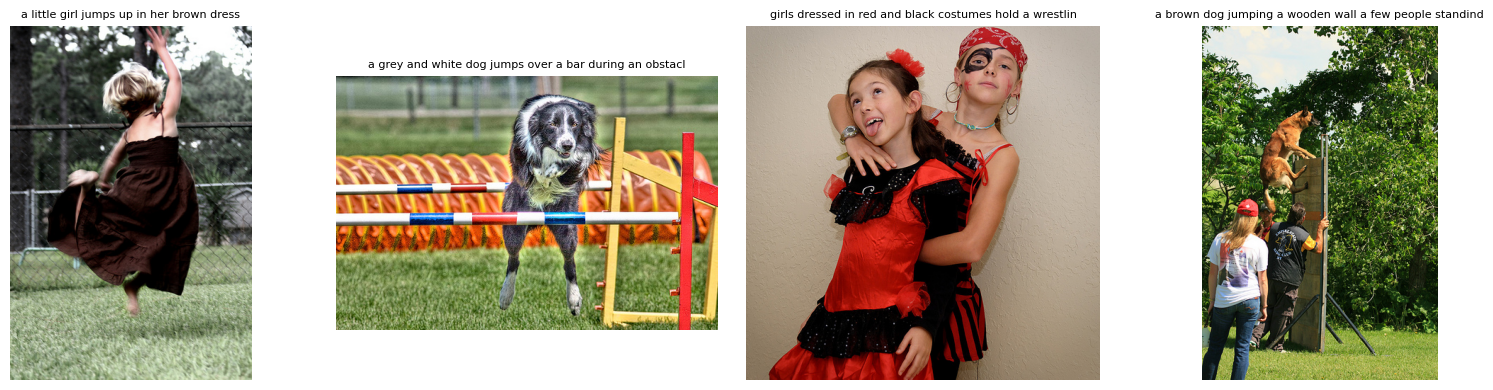

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, row) in zip(axes, train_df.sample(4, random_state=SEED).iterrows()):
    ax.imshow(Image.open(IMG_DIR / row["image"]).convert("RGB"))
    ax.set_title(row["caption"][:55], fontsize=8, wrap=True)
    ax.axis("off")
plt.tight_layout(); plt.show()


## 9 · Model Architecture

EfficientNet-B4 encoder (blocks 6-8 fine-tuned, single-scale features) feeding a 2-layer standard Transformer decoder with weight tying and beam search decoding. The encoder produces spatial visual tokens, while the decoder uses masked self-attention and cross-attention to generate a caption word by word.

In [12]:
class EncoderCNN(nn.Module):
    """EfficientNet-B4 backbone; only the last three blocks are fine-tuned."""

    def __init__(self, proj_dim=512, dropout=0.1):
        super().__init__()
        try:
            base = tvm.efficientnet_b4(weights=tvm.EfficientNet_B4_Weights.IMAGENET1K_V1)
        except Exception as _e:
            _msg = str(_e).lower()
            if any(k in _msg for k in ("name resolution", "urlopen", "gaierror", "connection")):
                raise RuntimeError(
                    "\n\nCannot download EfficientNet-B4 weights — internet is disabled.\n"
                    "  Kaggle : right panel -> Settings -> Internet -> ON  (session will restart)\n"
                    "  Colab  : Runtime -> Change runtime type -> confirm, then re-run\n"
                    "After enabling internet, re-run all cells from the top.\n"
                ) from None
            raise
        self.features = base.features
        self.dropout  = nn.Dropout2d(dropout)

        # Freeze everything except the top blocks — they're the most task-specific,
        # and fine-tuning fewer blocks overfits less on a small dataset.
        for p in self.features.parameters():
            p.requires_grad = False
        for blk_idx in [6, 7, 8]:
            for p in self.features[blk_idx].parameters():
                p.requires_grad = True

        self.proj_final = nn.Sequential(
            nn.Conv2d(1792, proj_dim, 1, bias=False),
            nn.BatchNorm2d(proj_dim), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        feat = self.features(x)
        feat = self.dropout(feat)
        f = self.proj_final(feat)
        B, C, H, W = f.shape
        return f.view(B, C, H * W).permute(0, 2, 1)   # (B, H*W, proj_dim)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.dropout(self.pe[:, :x.size(1)])


class TransformerDecoderLayer(nn.Module):
    """Standard self-attn + cross-attn decoder block."""

    def __init__(self, d_model, n_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model), nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        sa, _ = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask,
                               key_padding_mask=tgt_key_padding_mask, need_weights=False)
        tgt = self.norm1(tgt + sa)
        ca, _ = self.cross_attn(tgt, memory, memory, need_weights=False)
        tgt = self.norm2(tgt + ca)
        tgt = self.norm3(tgt + self.ff(tgt))
        return tgt


class CaptionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, n_layers=2,
                 ffn_dim=2048, max_len=52, dropout=0.3):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc = PositionalEncoding(d_model, max_len + 2, dropout)
        self.layers  = nn.ModuleList([
            TransformerDecoderLayer(d_model, n_heads, ffn_dim, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.fc_out  = nn.Linear(d_model, vocab_size)
        self.d_model = d_model
        self.n_heads = n_heads
        nn.init.xavier_uniform_(self.embed.weight)
        self.fc_out.weight = self.embed.weight   # weight tying
        nn.init.zeros_(self.fc_out.bias)

    @staticmethod
    def _causal_mask(sz, device):
        return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()

    def forward(self, memory, captions):
        tgt_tokens = captions[:, :-1]
        tgt_emb    = self.pos_enc(self.embed(tgt_tokens) * math.sqrt(self.d_model))
        T_tgt      = tgt_emb.size(1)
        causal     = self._causal_mask(T_tgt, memory.device)
        pad_mask   = (tgt_tokens == 0)   # True = ignore (PyTorch MHA convention)
        h = tgt_emb
        for layer in self.layers:
            h = layer(h, memory, tgt_mask=causal, tgt_key_padding_mask=pad_mask)
        return self.fc_out(h)

    @torch.no_grad()
    def generate_beam(self, memory, vocab, beam_width=3, max_len=48, length_penalty=0.7):
        self.eval()
        sos = vocab.stoi[vocab.SOS]; eos = vocab.stoi[vocab.EOS]
        pad = vocab.stoi[vocab.PAD]; unk = vocab.stoi[vocab.UNK]
        device = memory.device

        def _norm(raw, length):
            return raw / (((5 + length) / 6) ** length_penalty)

        beams = [(0.0, [sos])]
        done  = []
        for _ in range(max_len):
            if not beams:
                break
            next_beams = []
            for score, tokens in beams:
                if tokens[-1] == eos:
                    done.append((score, tokens))
                    continue
                ids  = torch.tensor([tokens], dtype=torch.long, device=device)
                emb  = self.pos_enc(self.embed(ids) * math.sqrt(self.d_model))
                mask = self._causal_mask(emb.size(1), device)
                h = emb
                for layer in self.layers:
                    h = layer(h, memory, tgt_mask=mask)
                logits   = self.fc_out(h[:, -1, :])
                log_prob = F.log_softmax(logits, dim=-1).squeeze(0)
                top_lp, top_id = log_prob.topk(beam_width)
                for tlp, tid in zip(top_lp.tolist(), top_id.tolist()):
                    next_beams.append((score + tlp, tokens + [tid]))
            if not next_beams:
                break
            next_beams.sort(key=lambda x: _norm(x[0], len(x[1])), reverse=True)
            beams = next_beams[:beam_width]
        if not done:
            done = [(b[0], b[1]) for b in beams]
        _, best = max(done, key=lambda x: _norm(x[0], len(x[1])))
        skip = {sos, eos, pad, unk}
        return [vocab.itos[i] for i in best if i not in skip]


## 10 · Model Initialization

Instantiates the encoder + decoder, optionally wraps them in `torch.compile`, prints parameter counts, and runs a forward-pass shape check to catch errors before training.

In [13]:
_encoder = EncoderCNN(proj_dim=PROJ_DIM, dropout=DROPOUT).to(DEVICE)
_decoder = CaptionDecoder(
    vocab_size=len(vocab), d_model=EMBED_SIZE, n_heads=N_HEADS,
    n_layers=N_LAYERS, ffn_dim=FFN_DIM, max_len=MAX_SEQ_LEN, dropout=DECODER_DROPOUT,
).to(DEVICE)

if USE_DP:
    encoder = nn.DataParallel(_encoder)
    decoder = nn.DataParallel(_decoder)
    print(f"DataParallel across {N_GPUS} GPUs")
else:
    encoder = _encoder
    decoder = _decoder
    print("Single-GPU mode")

# Static shapes (fixed image size + fixed-length padded captions) let torch.compile
# cache a single compiled graph instead of recompiling on every new shape.
if USE_COMPILE:
    try:
        encoder = torch.compile(encoder, dynamic=False)
        decoder = torch.compile(decoder, dynamic=False)
        print("torch.compile enabled (static shapes)")
    except Exception as _e:
        print(f"torch.compile skipped ({_e})")

enc_params = sum(p.numel() for p in _encoder.parameters())
dec_params = sum(p.numel() for p in _decoder.parameters())
print(f"Encoder: {enc_params:,}  |  Decoder: {dec_params:,}  |  Total: {enc_params+dec_params:,}")

with torch.no_grad():
    # >= 2 samples/GPU — a batch of 1 per GPU under DataParallel can trigger a
    # misaligned-address error inside EfficientNet's depthwise convs.
    _check_bs = 2 * max(1, N_GPUS)
    _f = encoder(torch.zeros(_check_bs, 3, 380, 380).to(DEVICE))
    _l = decoder(_f, torch.zeros(_check_bs, 10, dtype=torch.long).to(DEVICE))
    print(f"Encoder out: {_f.shape}  |  Decoder out: {_l.shape}")
print("Shape check passed.")


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 121MB/s] 


Single-GPU mode
torch.compile enabled (static shapes)
Encoder: 18,467,144  |  Decoder: 10,054,794  |  Total: 28,521,938


W0703 09:20:07.672000 58 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Encoder out: torch.Size([4, 144, 512])  |  Decoder out: torch.Size([4, 9, 3210])
Shape check passed.


## 11 · Loss, Optimizer & Scheduler

Configures cross-entropy loss, AdamW optimization, layer-wise encoder learning rates, mixed-precision scaling and the warmup-cosine learning-rate schedule.

The pretrained encoder uses smaller learning rates than the newly initialized decoder.

In [14]:
pad_idx   = vocab.stoi[vocab.PAD]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=LABEL_SMOOTHING)


def _enc_param_groups(enc_module, base_lr, decay=0.65):
    """Lower LR for earlier (more general) blocks, full LR for the projection head."""
    groups = []
    for i, blk_idx in enumerate([8, 7, 6]):
        groups.append({"params": list(enc_module.features[blk_idx].parameters()),
                       "lr": base_lr * (decay ** i), "name": f"enc_block{blk_idx}"})
    groups.append({"params": list(enc_module.proj_final.parameters()),
                   "lr": base_lr, "name": "enc_proj"})
    return groups


_param_groups = (
    _enc_param_groups(_encoder, ENCODER_LR)
    + [{"params": _decoder.parameters(), "lr": DECODER_LR, "name": "decoder"}]
)

try:
    optimizer = optim.AdamW(_param_groups, weight_decay=WEIGHT_DECAY, fused=USE_AMP)
    if USE_AMP:
        print("Fused AdamW")
except TypeError:
    optimizer = optim.AdamW(_param_groups, weight_decay=WEIGHT_DECAY)
    print("Standard AdamW (upgrade to PyTorch >= 2.0 for the fused version)")

try:
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)
except (TypeError, RuntimeError):
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def lr_lambda(epoch):
    """Linear warmup, then cosine decay down to MIN_LR_RATIO of the peak LR."""
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    p = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    cosine = 0.5 * (1.0 + math.cos(math.pi * p))
    return MIN_LR_RATIO + (1.0 - MIN_LR_RATIO) * cosine


scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print("Optimiser ready")
print("Param groups:", [(g["name"], f"{g['lr']:.1e}") for g in optimizer.param_groups])


Fused AdamW
Optimiser ready
Param groups: [('enc_block8', '1.1e-05'), ('enc_block7', '7.4e-06'), ('enc_block6', '4.8e-06'), ('enc_proj', '1.1e-05'), ('decoder', '4.3e-05')]


## 12 · BLEU Evaluation

A lightweight corpus-BLEU implementation and `evaluate_bleu`, which beam-decodes captions for a sample of images and scores them against the human references.

In [15]:
from collections import Counter as _C


def _ng(tok, n):
    return _C(tuple(tok[i:i+n]) for i in range(len(tok)-n+1))


def corpus_bleu(hyps, refs, max_n=4):
    out = {}
    for n in range(1, max_n+1):
        num = den = 0
        for h, rs in zip(hyps, refs):
            hng  = _ng(h, n)
            rmax = _C()
            for r in rs:
                for ng in (rng := _ng(r, n)):
                    rmax[ng] = max(rmax[ng], rng[ng])
            num += sum(min(c, rmax[ng]) for ng, c in hng.items())
            den += max(1, sum(hng.values()))
        out[f"bleu{n}"] = num / max(den, 1)
    return out


def evaluate_bleu(enc_module, dec_module, df, vocab, n=None):
    """Beam-decode captions for a sample of images and score them against the references."""
    if n is None:
        n = BLEU_EVAL_N
    enc_module.eval(); dec_module.eval()
    imgs = df["image"].unique().tolist()
    random.shuffle(imgs); imgs = imgs[:n]
    hyps, refs = [], []
    with torch.no_grad():
        for idx, name in enumerate(imgs):
            t = val_transform(Image.open(IMG_DIR / name).convert("RGB")).unsqueeze(0).to(DEVICE)
            f = enc_module(t)
            hyps.append(dec_module.generate_beam(f, vocab, BEAM_WIDTH, length_penalty=LENGTH_PENALTY))
            refs.append([r.split() for r in df[df["image"]==name]["caption"].tolist()])
            if USE_AMP and (idx + 1) % 50 == 0:
                torch.cuda.empty_cache()
    return corpus_bleu(hyps, refs)


## 13 · GPU / Forward-Pass Sanity Check

Confirms the model and a real batch are on the GPU and times one forward pass — a quick check before the long training run.

In [16]:
import subprocess, time

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count:   {torch.cuda.device_count()}")
print(f"DEVICE:         {DEVICE}")
print(f"USE_AMP:        {USE_AMP}")
print(f"USE_DP:         {USE_DP}")
print()

enc_device = next(_encoder.parameters()).device
dec_device = next(_decoder.parameters()).device
print(f"_encoder is on: {enc_device}")
print(f"_decoder is on: {dec_device}")
print()

imgs, caps, lengths = next(iter(train_loader))
print(f"Batch imgs device before .to(): {imgs.device}")
imgs = imgs.to(DEVICE, non_blocking=True)
caps = caps.to(DEVICE, non_blocking=True)
print(f"Batch imgs device after  .to(): {imgs.device}")
print()

torch.cuda.synchronize() if USE_AMP else None
t0 = time.time()
with torch.no_grad(), torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
    feat   = encoder(imgs)
    logits = decoder(feat, caps)
if USE_AMP: torch.cuda.synchronize()
print(f"Forward pass: {time.time()-t0:.3f}s  (should be <0.5s on GPU)")
print()

result = subprocess.run(
    ["nvidia-smi", "--query-gpu=index,utilization.gpu,memory.used,memory.total",
     "--format=csv,noheader,nounits"],
    capture_output=True, text=True,
)
print("nvidia-smi (index, util%, mem_used, mem_total):")
print(result.stdout.strip() if result.returncode == 0 else "nvidia-smi not available")


CUDA available: True
Device count:   2
DEVICE:         cuda
USE_AMP:        True
USE_DP:         False

_encoder is on: cuda:0
_decoder is on: cuda:0

Batch imgs device before .to(): cpu
Batch imgs device after  .to(): cuda:0

Forward pass: 112.831s  (should be <0.5s on GPU)

nvidia-smi (index, util%, mem_used, mem_total):
0, 95, 461, 15360
1, 0, 3, 15360


## 14 · Training Loop

Runs train + validation each epoch, evaluates BLEU periodically, saves two checkpoints (best val loss and best BLEU-4), and uses early stopping to halt once validation stops improving.

In [17]:
import shutil

train_losses, val_losses, bleu1s, bleu4s = [], [], [], []
best_val = math.inf
best_val_smoothed = math.inf
best_bleu4 = 0.0
epochs_no_improve = 0

if USE_AMP: torch.cuda.empty_cache()
print(f"Training {NUM_EPOCHS} epochs  |  device={DEVICE}  |  AMP={USE_AMP}  |  DP={USE_DP}")
print(f"Effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS}  |  early stopping patience: {PATIENCE}")
print(f"BLEU eval: every {EVAL_EVERY} epoch(s), {BLEU_EVAL_N} images\n")


def run_epoch(loader, train, epoch=0):
    encoder.train(train); decoder.train(train)
    tot, ntok = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    if train:
        optimizer.zero_grad(set_to_none=True)

    with ctx:
        for step, (imgs, caps, lengths) in enumerate(
            tqdm(loader, desc="train" if train else "val  ", leave=False)
        ):
            imgs = imgs.to(DEVICE, non_blocking=True)
            caps = caps.to(DEVICE, non_blocking=True)
            lengths = lengths.to(DEVICE, non_blocking=True)
            if train:
                imgs, caps, lengths = mixup_batch(imgs, caps, lengths, MIXUP_ALPHA, p=0.7)

            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                feat   = encoder(imgs)
                logits = decoder(feat, caps)
                tgt    = caps[:, 1:]
                loss   = criterion(logits.reshape(-1, len(vocab)), tgt.reshape(-1))
                if GRAD_ACCUM_STEPS > 1:
                    loss = loss / GRAD_ACCUM_STEPS

            if train:
                scaler.scale(loss).backward()
                is_last_step = (step == len(loader) - 1)
                if (step + 1) % GRAD_ACCUM_STEPS == 0 or is_last_step:
                    scaler.unscale_(optimizer)
                    trainable = ([p for p in _encoder.parameters() if p.requires_grad]
                                 + list(_decoder.parameters()))
                    nn.utils.clip_grad_norm_(trainable, MAX_GRAD_NORM)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

            mask  = tgt.reshape(-1) != pad_idx
            tot  += (loss.item() * GRAD_ACCUM_STEPS) * mask.sum().item()
            ntok += mask.sum().item()

    return tot / max(ntok, 1)


for epoch in range(1, NUM_EPOCHS + 1):
    if USE_AMP:
        torch.cuda.empty_cache()
    gc.collect()

    try:
        tl = run_epoch(train_loader, True, epoch)
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache(); gc.collect()
            print(f"\nOOM on training epoch {epoch}! "
                  f"Reduce BATCH_SIZE (currently {BATCH_SIZE}) in the hyperparameters cell and re-run.")
            break
        raise

    if USE_AMP: torch.cuda.empty_cache()

    try:
        vl = run_epoch(val_loader, False, epoch)
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            torch.cuda.empty_cache(); gc.collect()
            print(f"\nOOM on val epoch {epoch}! "
                  f"Reduce BATCH_SIZE (currently {BATCH_SIZE}) in the hyperparameters cell and re-run.")
            break
        raise

    scheduler.step()

    if epoch % EVAL_EVERY == 0:
        bleu   = evaluate_bleu(_encoder, _decoder, val_df, vocab)
        b1, b4 = bleu["bleu1"], bleu["bleu4"]
    else:
        b1 = bleu1s[-1] if bleu1s else float("nan")
        b4 = bleu4s[-1] if bleu4s else float("nan")

    train_losses.append(tl); val_losses.append(vl)
    bleu1s.append(b1);       bleu4s.append(b4)

    # Early stopping runs on a smoothed (3-epoch moving average) val loss — a single
    # unusually good or bad epoch on a small val set shouldn't trigger it on its own.
    SMOOTH_WINDOW = 3
    vl_smoothed = sum(val_losses[-SMOOTH_WINDOW:]) / len(val_losses[-SMOOTH_WINDOW:])

    dec_lr = optimizer.param_groups[-1]["lr"]
    enc_lr = optimizer.param_groups[0]["lr"]
    skip_marker = " (BLEU skipped)" if epoch % EVAL_EVERY != 0 else ""
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  train={tl:.4f}  val={vl:.4f}  "
          f"ppl={math.exp(min(vl,10)):.2f}  BLEU-1={b1:.3f}  BLEU-4={b4:.3f}  "
          f"enc_lr={enc_lr:.1e}  dec_lr={dec_lr:.1e}{skip_marker}")

    if vl < best_val:
        best_val = vl
        torch.save(_encoder.state_dict(), MODEL_DIR / "encoder_best.pth")
        torch.save(_decoder.state_dict(), MODEL_DIR / "decoder_best.pth")
        if DRIVE_DIR:
            shutil.copy(MODEL_DIR / "encoder_best.pth", Path(DRIVE_DIR) / "encoder_best.pth")
            shutil.copy(MODEL_DIR / "decoder_best.pth", Path(DRIVE_DIR) / "decoder_best.pth")
        print(f"  Best val-loss model saved (val={best_val:.4f})")

    if vl_smoothed < best_val_smoothed:
        best_val_smoothed = vl_smoothed
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # Val loss and BLEU-4 tend to peak at different epochs, so both checkpoints are
    # kept — use encoder_best_bleu.pth / decoder_best_bleu.pth for inference.
    if b4 > best_bleu4 and epoch % EVAL_EVERY == 0:
        best_bleu4 = b4
        torch.save(_encoder.state_dict(), MODEL_DIR / "encoder_best_bleu.pth")
        torch.save(_decoder.state_dict(), MODEL_DIR / "decoder_best_bleu.pth")
        if DRIVE_DIR:
            shutil.copy(MODEL_DIR / "encoder_best_bleu.pth", Path(DRIVE_DIR) / "encoder_best_bleu.pth")
            shutil.copy(MODEL_DIR / "decoder_best_bleu.pth", Path(DRIVE_DIR) / "decoder_best_bleu.pth")
        print(f"  Best BLEU-4 model saved (BLEU-4={best_bleu4:.3f}  val={vl:.4f})")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}: smoothed val loss has not improved for "
              f"{PATIENCE} epochs (best smoothed val={best_val_smoothed:.4f}, "
              f"best raw val={best_val:.4f}, best BLEU-4={best_bleu4:.3f}).")
        break


Training 30 epochs  |  device=cuda  |  AMP=True  |  DP=False
Effective batch: 64  |  early stopping patience: 10
BLEU eval: every 2 epoch(s), 200 images



train:   0%|          | 0/562 [00:00<?, ?it/s]

val  :   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 01/30  train=5.0525  val=4.2963  ppl=73.43  BLEU-1=nan  BLEU-4=nan  enc_lr=2.3e-05  dec_lr=8.6e-05 (BLEU skipped)
  Best val-loss model saved (val=4.2963)


train:   0%|          | 0/562 [00:00<?, ?it/s]

...

val  :   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 22/30  train=2.1613  val=3.0388  ppl=20.88  BLEU-1=0.677  BLEU-4=0.124  enc_lr=2.6e-05  dec_lr=9.9e-05
  Best BLEU-4 model saved (BLEU-4=0.124  val=3.0388)


train:   0%|          | 0/562 [00:00<?, ?it/s]

val  :   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 23/30  train=2.1250  val=3.0524  ppl=21.17  BLEU-1=0.677  BLEU-4=0.124  enc_lr=2.2e-05  dec_lr=8.2e-05 (BLEU skipped)

Early stopping at epoch 23: smoothed val loss has not improved for 10 epochs (best smoothed val=2.9721, best raw val=2.9679, best BLEU-4=0.124).


## 15 · Training Curves

Plots loss, perplexity, and BLEU over epochs. A widening train/val gap is the visual signature of overfitting.

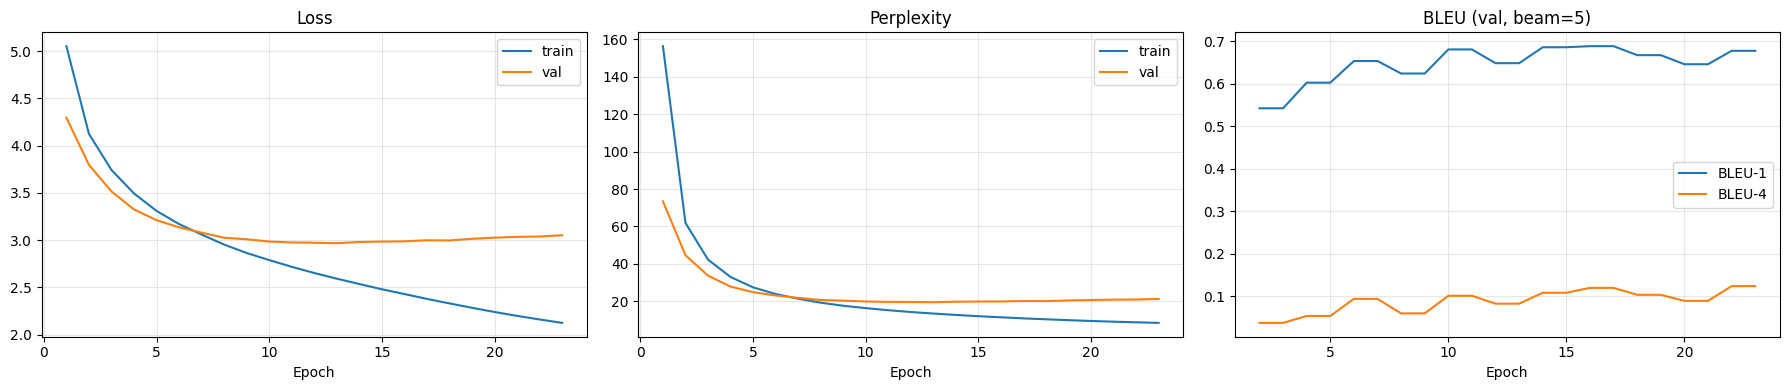

In [18]:
ep = range(1, len(train_losses)+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(ep, train_losses, label="train"); axes[0].plot(ep, val_losses, label="val")
axes[0].set(title="Loss", xlabel="Epoch"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(ep, [math.exp(min(l,10)) for l in train_losses], label="train")
axes[1].plot(ep, [math.exp(min(l,10)) for l in val_losses],   label="val")
axes[1].set(title="Perplexity", xlabel="Epoch"); axes[1].legend(); axes[1].grid(alpha=.3)

axes[2].plot(ep, bleu1s, label="BLEU-1"); axes[2].plot(ep, bleu4s, label="BLEU-4")
axes[2].set(title=f"BLEU (val, beam={BEAM_WIDTH})", xlabel="Epoch"); axes[2].legend(); axes[2].grid(alpha=.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / "curves.png", dpi=150)
plt.show()


## 16 · Save Final Artifacts

Saves the final weights, `config.json`, and vocab, and backs everything up to Drive. `inference.ipynb` only needs the contents of this `models/` folder plus the image directory.

In [19]:
torch.save(_encoder.state_dict(), MODEL_DIR / "encoder_final.pth")
torch.save(_decoder.state_dict(), MODEL_DIR / "decoder_final.pth")

cfg = dict(
    encoder="efficientnet_b4_singlescale", proj_dim=PROJ_DIM,
    decoder="transformer", embed_size=EMBED_SIZE,
    n_heads=N_HEADS, n_layers=N_LAYERS, ffn_dim=FFN_DIM,
    dropout=DROPOUT, vocab_size=len(vocab), max_seq_len=MAX_SEQ_LEN,
    beam_width=BEAM_WIDTH, length_penalty=LENGTH_PENALTY,
    best_val_loss=best_val,
    final_bleu1=bleu1s[-1] if bleu1s else None,
    final_bleu4=bleu4s[-1] if bleu4s else None,
    n_gpus=N_GPUS, grad_accum_steps=GRAD_ACCUM_STEPS,
    label_smoothing=LABEL_SMOOTHING, weight_decay=WEIGHT_DECAY,
    best_bleu4=best_bleu4,
)
with open(MODEL_DIR / "config.json", "w") as f:
    json.dump(cfg, f, indent=2)

if DRIVE_DIR:
    for fname in ["encoder_final.pth", "decoder_final.pth", "encoder_best_bleu.pth",
                  "decoder_best_bleu.pth", "vocab.pkl", "config.json", "test_captions.csv"]:
        src = MODEL_DIR / fname
        if src.exists():
            shutil.copy(src, Path(DRIVE_DIR) / fname)
    print(f"All artifacts backed up to Drive: {DRIVE_DIR}")

print("Saved locally:")
for p in sorted(MODEL_DIR.iterdir()):
    print(f"  {p.name}  {p.stat().st_size/1024:.1f} KB")


Saved locally:
  config.json  0.5 KB
  curves.png  95.9 KB
  decoder_best.pth  39398.6 KB
  decoder_best_bleu.pth  39398.9 KB
  decoder_final.pth  39398.7 KB
  encoder_best.pth  72884.4 KB
  encoder_best_bleu.pth  72888.1 KB
  encoder_final.pth  72885.1 KB
  test_captions.csv  39.2 KB
  vocab.pkl  62.2 KB
